# Block 5 - Statistical Validation

This notebook builds on the exploratory SQL analysis from Notebook **`01_retail_basket_analysis.ipynb`** and supports the findings with visual analysis and statistical validation whether the differences in basket value observed across demographic segments are statistically significant, or could be due to chance.

**Main question:**
Is the difference in average basket value across income groups statistically significant?

## Setup & Imports
Standard data analysis libraries plus `scipy.stats` for hypothesis testing and `plotly` for interactive visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from google.cloud import bigquery
import plotly.graph_objects as go

# BigQuery client
client = bigquery.Client(project="final-project-dla")
print("Connected to BigQuery")


Connected to BigQuery


## Data Loading

Four datasets are loaded directly from BigQuery:
- **df_baskets** — all baskets with value and item count
- **df_income** — basket-level data joined with household income
- **df_households** — household-level aggregated stats
- **df_household_profile** — household-level stats with full demographic profile

All four will be used across different sections of this notebook.

In [2]:
# Load basket-level data 
df_baskets = client.query("""
    SELECT basket_value, total_items
    FROM `final-project-dla.raw_data.basket_summary`
""").to_dataframe()

# Load basket + income data
df_income = client.query("""
    SELECT
        b.household_key,
        b.basket_value,
        d.income_desc AS income_group
    FROM `final-project-dla.raw_data.basket_summary` b
    JOIN `final-project-dla.raw_data.hh_demographic_raw` d
        ON b.household_key = d.household_key
""").to_dataframe()

# Load household-level stats
df_households = client.query("""
    SELECT
        b.household_key,
        COUNT(DISTINCT b.basket_id)     AS total_visits,
        SUM(b.basket_value)             AS total_spend,
        AVG(b.basket_value)             AS avg_basket_value,
        AVG(b.unique_products)          AS avg_unique_products,
        MAX(b.day) - MIN(b.day)         AS active_days
    FROM `final-project-dla.raw_data.basket_summary` b
    GROUP BY b.household_key
""").to_dataframe()

# Load demographic data
df_household_profile = client.query("""
    SELECT
        b.household_key,
        AVG(b.basket_value)         AS avg_basket_value,
        SUM(b.basket_value)         AS total_spend,
        COUNT(DISTINCT b.basket_id) AS total_visits,
        d.age_desc                  AS age_group,
        d.income_desc               AS income_group,
        d.kid_category_desc         AS kid_category
    FROM `final-project-dla.raw_data.basket_summary` b
    JOIN `final-project-dla.raw_data.hh_demographic_raw` d
        ON b.household_key = d.household_key
    GROUP BY
        b.household_key, d.age_desc,
        d.income_desc, d.kid_category_desc
""").to_dataframe()

print(f"df_baskets: {df_baskets.shape}")
print(f"df_income: {df_income.shape}")
print(f"df_households: {df_households.shape}")
print(f"df_household_profile: {df_household_profile.shape}")


df_baskets: (275539, 2)
df_income: (139871, 3)
df_households: (2500, 6)
df_household_profile: (801, 7)


Dataset shapes confirm expected row counts:
- `df_baskets` — 275,539 baskets (full dataset)
- `df_income` — 139,871 baskets with income data (demographic subset)
- `df_households` — 2,500 unique households
- `df_household_profile` — 801 households with full demographic data

## Quick Data Validation

A quick descriptive overview of all four datasets to verify expected shapes, distributions, and group sizes before proceeding.

In [3]:
# Quick validation
print("-" * 65)
print("  df_baskets")
print("-" * 65)
print(df_baskets.describe().round(2))

print("-" * 65)
print("  df_income")
print("-" * 65)
print(df_income["income_group"].value_counts())

print("-" * 65)
print("  df_households")
print("-" * 65)
print(df_households.describe().round(2))

print("-" * 65)
print("  df_household_profile")
print("-" * 65)
print(df_household_profile.describe().round(2))
print(df_household_profile["age_group"].value_counts())
print(df_household_profile["kid_category"].value_counts())


-----------------------------------------------------------------
  df_baskets
-----------------------------------------------------------------
       basket_value  total_items
count     275539.00     275539.0
mean          29.24       946.08
std           36.12      3425.84
min            0.01          1.0
25%            6.99          3.0
50%           17.18          8.0
75%           36.39         22.0
max          961.49      89638.0
-----------------------------------------------------------------
  df_income
-----------------------------------------------------------------
income_group
50-74K       32134
35-49K       29524
25-34K       15190
75-99K       14262
Under 15K    12723
15-24K       12097
125-149K      7625
100-124K      6329
150-174K      4930
250K+         2394
175-199K      2092
200-249K       571
Name: count, dtype: int64
-----------------------------------------------------------------
  df_households
-----------------------------------------------------------------

Key observations:
- `df_baskets` confirms the earlier finding - mean items (**946**) is heavily distorted by KIOSK-GAS outliers, median (**8**) is the reliable figure
- `df_income` - **50-74K** is the largest income group (**32,134 baskets**), **200-249K** is the smallest (**571**) - important to keep in mind when interpreting statistical results for small groups
- `df_households` - median total spend is **$2,157** and median visits are **78** per household across all 2,500 customers
- `df_household_profile` - 801 households with demographics, **45-54** is the largest age group (**288**), **19-24** the smallest (**46**)
- Kid category is dominated by **None/Unknown (558)** - as noted in the main notebook, this doesn't necessarily mean child-free households

## Categorical Ordering

Demographic columns are converted to ordered categoricals to ensure correct sorting in all subsequent analyses and visualizations.

In [4]:
# Categorical ordering

age_order = ["19-24", "25-34", "35-44", "45-54", "55-64", "65+"]

income_order = [
    "Under 15K",
    "15-24K",
    "25-34K",
    "35-49K",
    "50-74K",
    "75-99K",
    "100-124K",
    "125-149K",
    "150-174K",
    "175-199K",
    "200-249K",
    "250K+",
]

kid_order = ["None/Unknown", "1", "2", "3+"]


def apply_categorical(df, col, order):
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)


# Apply ordering
apply_categorical(df_income, "income_group", income_order)
apply_categorical(df_household_profile, "age_group", age_order)
apply_categorical(df_household_profile, "income_group", income_order)
apply_categorical(df_household_profile, "kid_category", kid_order)

print("Categorical ordering applied")


Categorical ordering applied


## Data Validation

Before running any statistical tests, we verify:
- No null values in any dataset
- Household keys are unique where expected
- Revenue totals match between `df_baskets` and `df_households`

In [5]:
# Sanity checks
dataframes = {
    "df_baskets": df_baskets,
    "df_income": df_income,
    "df_households": df_households,
    "df_household_profile": df_household_profile,
}

print("-" * 65)
print("  Nulls")
print("-" * 65)
for name, df in dataframes.items():
    nulls = df.isnull().sum().sum()
    print(f"{name:<25} nulls: {nulls}")
    if nulls > 0:
        print(df.isnull().sum()[df.isnull().sum() > 0])

print("-" * 65)
print("  Uniqueness checks")
print("-" * 65)
print(
    f"df_households - unique households: "
    f"{df_households['household_key'].nunique()} / {len(df_households)}"
)
print(
    f"df_household_profile - unique households: "
    f"{df_household_profile['household_key'].nunique()} / {len(df_household_profile)}"
)
print(f"df_income - unique income groups: {df_income['income_group'].nunique()}")
print(
    f"df_household_profile - unique age groups: "
    f"{df_household_profile['age_group'].nunique()}"
)

print("-" * 65)
print("  Revenue check")
print("-" * 65)
basket_revenue = df_baskets["basket_value"].sum()
household_revenue = df_households["total_spend"].sum()

print(f"df_baskets total revenue: ${basket_revenue:,.2f}")
print(f"df_households total revenue: ${household_revenue:,.2f}")
print(f"Revenue match: {round(basket_revenue, 2) == round(household_revenue, 2)}")


-----------------------------------------------------------------
  Nulls
-----------------------------------------------------------------
df_baskets                nulls: 0
df_income                 nulls: 0
df_households             nulls: 0
df_household_profile      nulls: 0
-----------------------------------------------------------------
  Uniqueness checks
-----------------------------------------------------------------
df_households - unique households: 2500 / 2500
df_household_profile - unique households: 801 / 801
df_income - unique income groups: 12
df_household_profile - unique age groups: 6
-----------------------------------------------------------------
  Revenue check
-----------------------------------------------------------------
df_baskets total revenue: $8,057,443.80
df_households total revenue: $8,057,443.80
Revenue match: True


All checks passed:
- Zero nulls across all four datasets
- 2,500 unique households in `df_households`
- 801 unique households in `df_household_profile`
- Revenue match confirmed - **$8,057,443.80** in both datasets

Data is clean and consistent - ready for statistical analysis.

## Basket Value Distribution

Before running hypothesis tests, we visualize the overall basket value distribution to understand its shape and confirm whether parametric or non-parametric tests are appropriate.

Baskets above $200 are excluded from the view for clarity - they represent 5.2% of total baskets and are visible in the descriptive stats but would compress the main distribution if included.

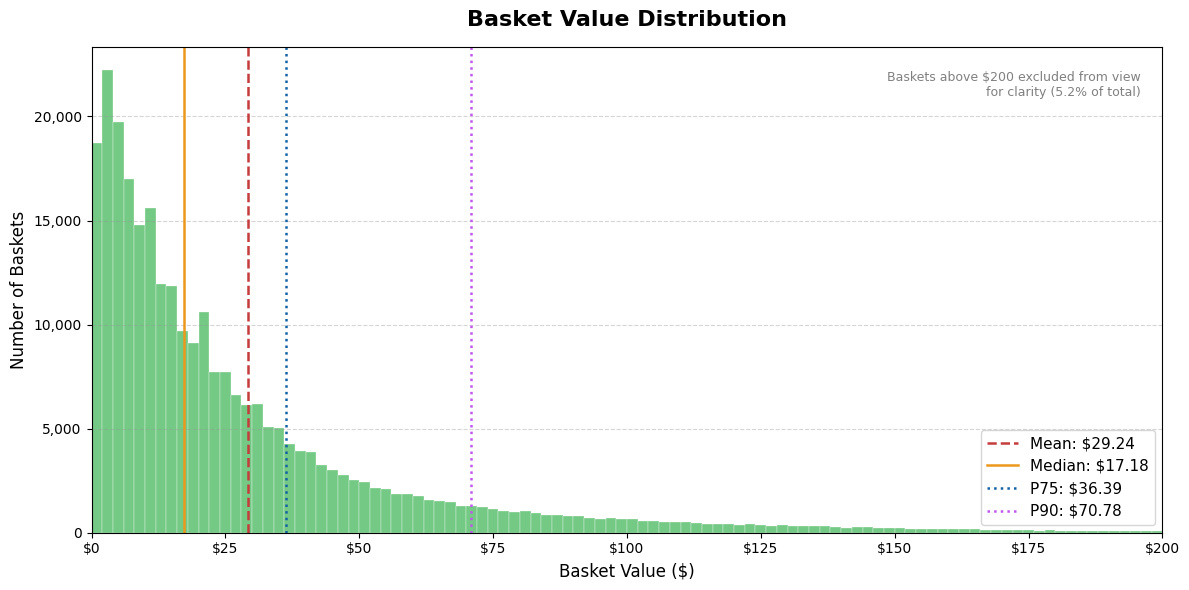

Chart saved


In [6]:
# Calculate statistics
mean_val = df_baskets["basket_value"].mean()
median_val = df_baskets["basket_value"].median()
p75_val = df_baskets["basket_value"].quantile(0.75)
p90_val = df_baskets["basket_value"].quantile(0.90)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    df_baskets["basket_value"],
    bins=100,
    range=(0, 200),
    color="#46B85B",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3,
)

# Annotation lines
lines = {
    f"Mean: ${mean_val:.2f}": (mean_val, "#C53C3C", "--"),
    f"Median: ${median_val:.2f}": (median_val, "#EB981C", "-"),
    f"P75: ${p75_val:.2f}": (p75_val, "#1262A4", ":"),
    f"P90: ${p90_val:.2f}": (p90_val, "#BF58EB", ":"),
}

for label, (val, color, style) in lines.items():
    ax.axvline(val, color=color, linestyle=style, linewidth=1.8, label=label)

# Formatting
ax.set_title("Basket Value Distribution", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Basket Value ($)", fontsize=12)
ax.set_ylabel("Number of Baskets", fontsize=12)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=11)
ax.set_xlim(0, 200)
ax.grid(axis="y", color="#979797", linewidth=0.8, linestyle="--", alpha=0.4)
ax.annotate(
    "Baskets above $200 excluded from view\nfor clarity (5.2% of total)",
    xy=(0.98, 0.95),
    xycoords="axes fraction",
    fontsize=9,
    color="gray",
    ha="right",
    va="top",
)

plt.tight_layout()
plt.savefig("basket_value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")


**Observations:**
- Distribution is strongly **right-skewed** - the long tail to the right confirms that most baskets are small, with a minority of high-value outliers
- **Median ($17.18)** sits well below the **mean ($29.24)** - a classic sign of skew where large baskets pull the average upward
- **75% of baskets fall below $36.39** and **90% below $70.78** - the majority of shopping trips are routine, low-value visits
- The skewed, non-normal distribution confirms that **parametric tests (e.g. ANOVA) are not appropriate** here - we will use the **Kruskal-Wallis test** instead, which does not assume normality

## Basket Value Distribution by Income Group

Before running the Kruskal-Wallis test, we visualize basket value distributions across all 12 income groups using box plots. The dashed line inside each box represents the **mean**, the solid line represents the **median**.

In [7]:
# Plot
fig = go.Figure()

# Add one box plot per income group
for income in income_order:
    data = df_income[df_income["income_group"] == income]["basket_value"]
    fig.add_trace(
        go.Box(
            y=data,
            name=income,
            marker_color="#105522",
            line_color="#25834C",
            fillcolor="#7FB089",
            opacity=0.75,
            boxmean=True,
            hovertemplate=(f"<b>{income}</b><br>Value: $%{{y:.2f}}<extra></extra>"),
        )
    )

# Formatting
fig.update_layout(
    title=dict(
        text="Basket Value Distribution by Income Group",
        font=dict(size=18, color="#1A1A1A"),
        x=0.5,
    ),
    xaxis=dict(title="Income Group", tickfont=dict(size=11)),
    yaxis=dict(
        title="Basket Value ($)",
        tickprefix="$",
        tickformat=",.0f",
        range=[0, 250],
    ),
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=550,
    margin=dict(b=80),
    annotations=[
        dict(
            text="Baskets above $250 excluded for clarity",
            xref="paper",
            yref="paper",
            x=0.98,
            y=-0.18,
            showarrow=False,
            font=dict(size=10, color="gray"),
            xanchor="right",
        )
    ],
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor="#EEEEEE")

fig.show()
print("Chart rendered")


Chart rendered


**Observations:**
- A clear **upward trend** in both median and mean basket value is visible from left to right - lower income groups cluster near **$15–$20 median**, while higher income groups reach **$35–$50**
- All groups show significant right skew and numerous outliers above the whiskers - consistent with the overall distribution seen earlier
- **150-174K, 200-249K, and 250K+** show notably wider IQR boxes - higher income households have more variable spending behavior
- **100-124K** appears to have a lower mean than neighboring groups - consistent with the anomaly noted in the main notebook

**Note:** Baskets above $250 are excluded from view for clarity - they are included in all statistical calculations.

## Correlation Matrix - Household Shopping Metrics

To better understand relationships between key household-level metrics, we compute a Pearson correlation matrix across 5 variables:
- **Total Visits** - how often a household shops
- **Avg Basket Value** - average spend per trip
- **Total Spend** - overall revenue contribution
- **Avg Unique Products** - basket diversity
- **Active Days** - length of engagement with the store

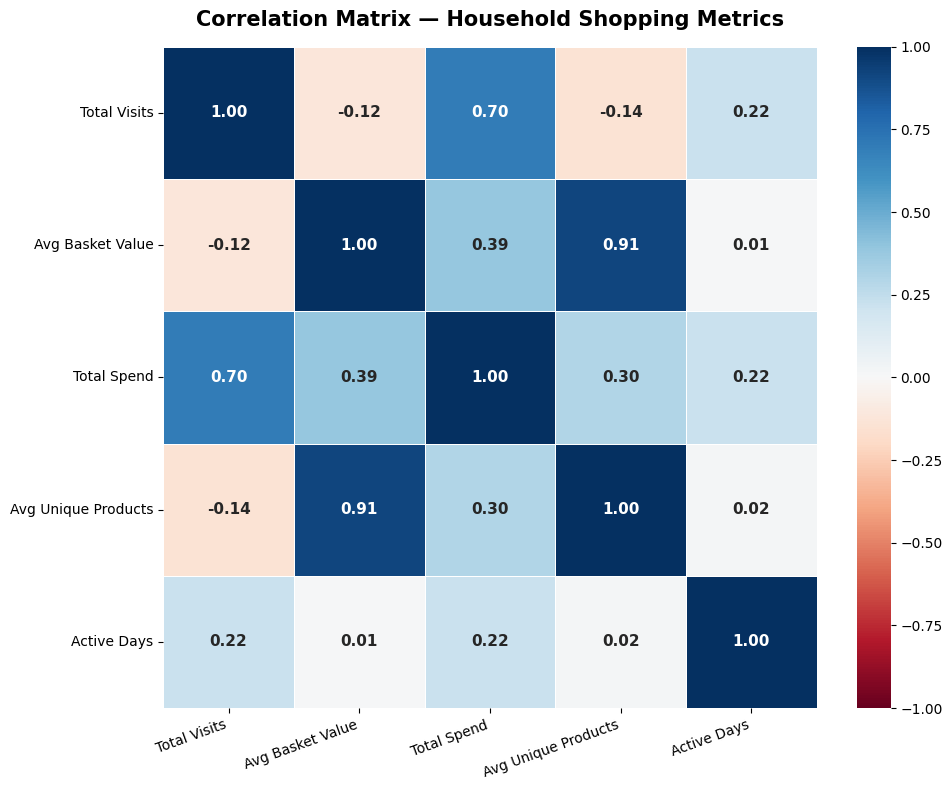

Chart saved


In [8]:
corr_cols = [
    "total_visits",
    "avg_basket_value",
    "total_spend",
    "avg_unique_products",
    "active_days",
]

corr_matrix = df_households[corr_cols].corr()

# Rename for display
corr_matrix.columns = [
    "Total Visits",
    "Avg Basket Value",
    "Total Spend",
    "Avg Unique Products",
    "Active Days",
]
corr_matrix.index = corr_matrix.columns

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 11, "weight": "bold"},
    ax=ax,
)

# Formatting
ax.set_title(
    "Correlation Matrix — Household Shopping Metrics",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=20, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")


**Observations:**
- **Avg Basket Value vs Avg Unique Products (0.91)** - the strongest correlation in the matrix. Households that buy more diverse products 
per trip naturally spend more - basket diversity is the primary driver of basket value
- **Total Visits vs Total Spend (0.70)** - confirms the earlier finding from the loyalty analysis: frequency is the main driver of overall 
customer value
- **Total Visits vs Avg Basket Value (-0.12)** - weak negative correlation, consistent with the loyalty tier finding - frequent shoppers tend to 
make smaller, more routine trips
- **Active Days vs Total Spend (0.22)** - weak positive relationship - longer engagement period contributes to spend but is not a strong 
predictor on its own
- **Active Days vs Avg Basket Value (0.01)** - essentially no relationship - how long a customer has been active has no bearing on how much 
they spend per trip

**Key insight:** Basket value is driven by **product diversity**, not frequency. Total customer value is driven by **visit frequency**. These are two distinct behavioral dimensions that should inform different types of interventions - assortment expansion vs visit frequency programs.

## Median Average Basket Value by Age Group & Kid Category

This heatmap combines two demographic dimensions - age group and household kid category - to reveal interaction effects that individual segment analysis might miss.

Each cell shows the **median average basket value** for that combination, along with **n=** sample size. Cells with very small sample sizes (n < 10) should be interpreted with caution.

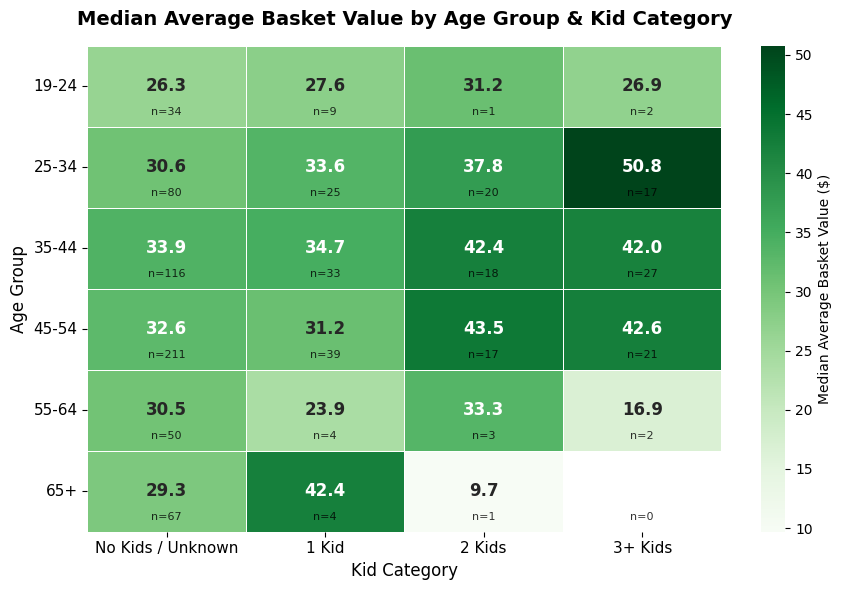

Chart saved


In [9]:
# Pivot table for median basket value
pivot = df_household_profile.pivot_table(
    values="avg_basket_value",
    index="age_group",
    columns="kid_category",
    aggfunc="median",
    observed=False,
)

# Reorder axes
pivot = pivot.reindex(index=age_order, columns=kid_order)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
    cbar_kws={"label": "Median Average Basket Value ($)"},
    ax=ax,
)

# Formatting
ax.set_title(
    "Median Average Basket Value by Age Group & Kid Category",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Kid Category", fontsize=12)
ax.set_ylabel("Age Group", fontsize=12)
ax.set_xticklabels(
    ["No Kids / Unknown", "1 Kid", "2 Kids", "3+ Kids"], fontsize=11, rotation=0
)
ax.set_yticklabels(age_order, fontsize=11, rotation=0)

# Add sample size labels
counts = df_household_profile.pivot_table(
    values="avg_basket_value",
    index="age_group",
    columns="kid_category",
    aggfunc="count",
    observed=False,
).reindex(index=age_order, columns=kid_order)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        count = counts.iloc[i, j]
        if not pd.isna(count):
            ax.text(
                j + 0.5,
                i + 0.82,
                f"n={int(count)}",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                alpha=0.8,
            )
            
plt.tight_layout()
plt.savefig("age_kids_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")


**Observations:**
- **25-34 with 3+ kids ($50.8)** is the highest spending combination - young families with multiple children are the most valuable segment by median basket value. However **n=12** warrants some caution
- **35-44 and 45-54 with 2+ kids** consistently show high median values (**$42–$43**) with more reliable sample sizes
- **No Kids/Unknown** basket values increase through middle age (peaking at 35-44: **$33.9**) then decline for older groups - consistent with the age group findings from the main notebook
- **65+ with 2 kids ($9.7, n=1)** is a single observation and should be disregarded
- **55-64 with 1 kid ($23.9, n=4)** and **65+ with 1 kid ($42.4, n=4)** have very small samples - treat as indicative only

**Key insight:** The most impactful demographic combination is **young-to-middle-aged households with multiple children** - they consistently show the highest basket values across the matrix. Cells with n < 10 should not be used for business decisions without additional data.

## Kruskal-Wallis Test

**Hypothesis:**
- **H₀ (null):** The distribution of basket values is the same across all income groups
- **H₁ (alternative):** At least one income group has a significantly different basket value distribution

**Why Kruskal-Wallis?**
It is the non-parametric equivalent of one-way ANOVA - appropriate here because the basket value distribution is strongly right-skewed and 
does not meet the normality assumption required for ANOVA. The test compares rank distributions across all 12 income groups simultaneously.

In [10]:
# Prepare basket value arrays for each income group
groups = [
    group["basket_value"].values
    for _, group in df_income.groupby("income_group", observed=True)
]

# Run Kruskal-Wallis test
stat, p_value = stats.kruskal(*groups)

print("=" * 55)
print("  Kruskal-Wallis Test: Basket Value Across Income Groups")
print("=" * 55)
print(f"  Test statistic : {stat:.4f}")
print(f"  P-value        : {p_value:.2e}")
print(f"  Groups tested  : {df_income['income_group'].nunique()}")
print(f"  Total baskets  : {len(df_income):,}")
print("-" * 55)
if p_value < 0.05:
    print("  Result: SIGNIFICANT ✓")
    print("  The difference in basket values across income groups")
    print("  is statistically significant (p < 0.05).")
else:
    print("  Result: NOT SIGNIFICANT")
    print("  No statistically significant difference detected.")
print("=" * 55)


  Kruskal-Wallis Test: Basket Value Across Income Groups
  Test statistic : 6049.4706
  P-value        : 0.00e+00
  Groups tested  : 12
  Total baskets  : 139,871
-------------------------------------------------------
  Result: SIGNIFICANT ✓
  The difference in basket values across income groups
  is statistically significant (p < 0.05).


**Result: Statistically Significant**

- **Test statistic: 6049.47** - extremely large, indicating substantial differences in rank distributions across groups
- **P-value: ~0.00** - effectively zero, far below the 0.05 threshold
- Tested across **12 income groups** and **139,871 baskets**

We **reject the null hypothesis** - the differences in basket value across income groups are statistically significant and are extremely 
unlikely to be due to chance.

However, Kruskal-Wallis only tells us that **at least one group differs** - it does not tell us **which groups** differ from each other. Post-hoc analysis is required to identify the specific pairs.

## Income Group Summary Table

A structured summary of basket value statistics per income group, ordered from lowest to highest income. The **Median** column is 
highlighted with a green gradient to visually reinforce the income-to-basket-value relationship tested by Kruskal-Wallis.

This table serves as the descriptive companion to the hypothesis test - showing the actual values behind the statistically significant result.

In [11]:
income_group_summary = (
    df_income.groupby("income_group", observed=True)["basket_value"]
    .agg(
        basket_count="count",
        mean="mean",
        median="median",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .round(2)
    .reset_index()
)

income_group_summary.columns = [
    "Income Group",
    "Basket Count",
    "Mean ($)",
    "Median ($)",
    "P25 ($)",
    "P75 ($)",
]

income_group_summary.style.background_gradient(
    subset=["Median ($)"], cmap="Greens"
).format(
    {
        "Basket Count": "{:,}",
        "Mean ($)": "${:.2f}",
        "Median ($)": "${:.2f}",
        "P25 ($)": "${:.2f}",
        "P75 ($)": "${:.2f}",
    }
).hide(axis="index")


Income Group,Basket Count,Mean ($),Median ($),P25 ($),P75 ($)
Under 15K,"12,723",$26.66,$15.81,$6.31,$34.17
15-24K,"12,097",$25.06,$15.32,$6.85,$31.29
25-34K,"15,190",$25.03,$13.24,$4.86,$29.99
35-49K,"29,524",$27.98,$16.84,$6.68,$33.82
50-74K,"32,134",$34.07,$21.83,$9.11,$43.52
75-99K,"14,262",$39.19,$25.62,$11.98,$51.33
100-124K,"6,329",$31.84,$22.60,$10.00,$41.46
125-149K,"7,625",$39.43,$23.51,$7.88,$47.22
150-174K,"4,930",$51.08,$34.06,$15.98,$68.55
175-199K,"2,092",$44.95,$30.75,$18.01,$54.97


**Observations:**
- Median basket value rises clearly from **$13.24** (25-34K) to **$34.79** (250K+) - a **2.6x difference** between the lowest and highest income groups
- **150-174K** shows the highest mean (**$51.08**) - slightly above 250K+ - consistent with the anomaly noted in earlier analysis
- **100-124K** continues to underperform relative to neighboring groups - median of **$22.60** vs **$25.62** for 75-99K and **$23.51** for 125-149K
- **200-249K** has the smallest sample (**571 baskets**) - results for this group carry more uncertainty than others
- The P25-P75 range widens with income - higher income groups show more variable spending behavior, while lower income groups are more consistent in their basket sizes

**Note:** These descriptive statistics directly support the Kruskal-Wallis result - the differences visible here are confirmed to be statistically significant, not due to chance.

# Summary - Statistical Validation

## Key Results

**Kruskal-Wallis Test - Basket Value Across Income Groups**
- Test statistic: **6049.47**, p-value: **~0.00**
- The null hypothesis is **rejected** - differences in basket value across income groups are statistically significant and not due to chance
- This validates the descriptive findings from the main notebook: income is a genuine driver of basket value, not a coincidental pattern

## Supporting Findings

**Basket value distribution:**
- Strongly right-skewed  median ($17.18) is the more reliable central tendency measure than the mean ($29.24)
- Justifies the use of Kruskal-Wallis over parametric ANOVA

**Income group differences:**
- Median basket value ranges from **$13.24** (25-34K) to **$34.79** (250K+) - a 2.6x difference confirmed as statistically significant
- Higher income groups show wider spending variability (larger IQR)

**Correlation analysis:**
- Strongest relationship: **Avg Basket Value vs Avg Unique Products (0.91)** - basket diversity is the primary driver of basket value
- Visit frequency drives **total spend (0.70)** but not basket size (-0.12) - frequency and basket value are independent behavioral dimensions

**Combined demographic effect:**
- Young-to-middle-aged households with multiple children (**25-34, 3+ kids**) show the highest median basket values
- Small sample sizes in some demographic combinations limit the reliability of specific cell-level conclusions

## Business Recommendations

**1. Use income segmentation for targeted promotions**  
The 2.6x difference in median basket value across income groups is statistically confirmed - not coincidental. Higher income segments ($150K+) respond to premium and fresh category offers (PRODUCE, DELI), while lower income segments prioritize staples (MEAT, packaged goods). Tailoring promotions by income tier would improve relevance and conversion.

**2. Focus basket growth strategy on product diversity**  
The strongest finding in this notebook is the 0.91 correlation between basket diversity and basket value. Strategies that encourage customers 
to explore more categories - cross-category promotions, "complete the meal" suggestions, or bundled offers - are likely to be more effective 
at growing basket value than pure discount strategies.

**3. Treat frequency and basket value as separate levers**  
These are statistically independent behavioral dimensions. Frequency programs (visit rewards, streak bonuses) and basket growth programs (category exploration, bundle deals) should be designed and measured separately - combining them into one metric risks optimizing for neither.  

## Conclusion
The statistical analysis confirms that income-based differences in basket value are real and significant. Combined with the behavioral insights from the correlation and demographic analysis, this suggests that customer value can be grown through two distinct levers:
- **Basket size** - driven by product diversity, income level, and family composition
- **Visit frequency** - driven by loyalty and engagement programs